# Exploratory Data Analysis (EDA)

## Imports

In [23]:
from utils.data.database_connection import get_engine
from utils.data.queries import execute_query
import utils.plots.plot_utils as plot_utils
from sqlalchemy import text
import pandas as pd
import seaborn as sns
from itertools import combinations
import importlib

importlib.reload(plot_utils)

<module 'utils.plots.plot_utils' from 'F:\\Software\\Dataspell\\AdvertisementGroupClassification\\utils\\plots\\plot_utils.py'>

## Load Data

In [24]:
df = execute_query(
    "SELECT * FROM ml_dataset LIMIT :limit",
    limit=50000
)

## Data Overview

In [25]:
df.head()

,category_id,group_id,category_name,group_name,name
0,23,489,Mobilni telefoni,Apple iPhone,iPhone 8 64gb BH 85% DOBAR
1,23,489,Mobilni telefoni,Apple iPhone,iphone 14 yellow 128gb
2,23,489,Mobilni telefoni,Apple iPhone,OTKUP iPhone 11 Pro / Pro Max
3,23,489,Mobilni telefoni,Apple iPhone,Apple iPhone 15 128GB Black
4,23,489,Mobilni telefoni,Apple iPhone,iPhone 11 Pro 64gb otvoren na sve mreze (sim-f...


In [26]:
df.tail()

,category_id,group_id,category_name,group_name,name
49995,213,769,"Nakit, satovi i dragocenosti","Upaljači, tabakere i pljoske",COHIBA kožna futrola za 3 tompusa+poklon sekač...
49996,213,769,"Nakit, satovi i dragocenosti","Upaljači, tabakere i pljoske","COHIBA upaljac, brener x3 plamena + Sekač za t..."
49997,213,769,"Nakit, satovi i dragocenosti","Upaljači, tabakere i pljoske",davidoff brener upaljac
49998,213,769,"Nakit, satovi i dragocenosti","Upaljači, tabakere i pljoske",Putni humidor za ukupno 20 tompusa
49999,213,769,"Nakit, satovi i dragocenosti","Upaljači, tabakere i pljoske",glo hyper +


In [27]:
df.shape

(50000, 5)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   category_id    50000 non-null  int64 
 1   group_id       50000 non-null  int64 
 2   category_name  50000 non-null  object
 3   group_name     50000 non-null  object
 4   name           50000 non-null  object
dtypes: int64(2), object(3)
memory usage: 1.9+ MB


In [29]:
df.describe(include='all')

,category_id,group_id,category_name,group_name,name
count,50000.000000,50000.000000,50000,50000,50000
unique,NaN,NaN,10,10,42765
top,NaN,NaN,Mobilni telefoni,Apple iPhone,Krevet
freq,NaN,NaN,5000,5000,215
mean,577.300000,1071.200000,NaN,NaN,NaN
std,471.791333,749.385743,NaN,NaN,NaN
min,15.000000,232.000000,NaN,NaN,NaN
25%,26.000000,489.000000,NaN,NaN,NaN
50%,542.500000,871.000000,NaN,NaN,NaN
75%,1017.000000,1277.000000,NaN,NaN,NaN


## Data Quality Check

### Missing Values

In [30]:
df.isna().sum()

category_id      0
group_id         0
category_name    0
group_name       0
name             0
dtype: int64

### Duplicated Values

In [31]:
df.duplicated().sum()

7230

In [32]:
duplicates = df[df.duplicated(keep=False, subset="name")]

In [33]:
duplicates.head()

,category_id,group_id,category_name,group_name,name
8,23,489,Mobilni telefoni,Apple iPhone,iphone 11 pro
12,23,489,Mobilni telefoni,Apple iPhone,iPhone 13
13,23,489,Mobilni telefoni,Apple iPhone,iPhone 11 64gb
66,23,489,Mobilni telefoni,Apple iPhone,Iphone 11
101,23,489,Mobilni telefoni,Apple iPhone,iPhone 16 Pro


### Data Types

In [34]:
df.dtypes

category_id       int64
group_id          int64
category_name    object
group_name       object
name             object
dtype: object

In [35]:
for column in df.select_dtypes(include=["object"]):
    print(df[column].apply(type).value_counts())
    print("-----")

category_name
<class 'str'>    50000
Name: count, dtype: int64
-----
group_name
<class 'str'>    50000
Name: count, dtype: int64
-----
name
<class 'str'>    50000
Name: count, dtype: int64
-----


# Univariate Analysis

In [36]:
num_cols = df.select_dtypes(include=["number"]).columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns

### Numerical Columns

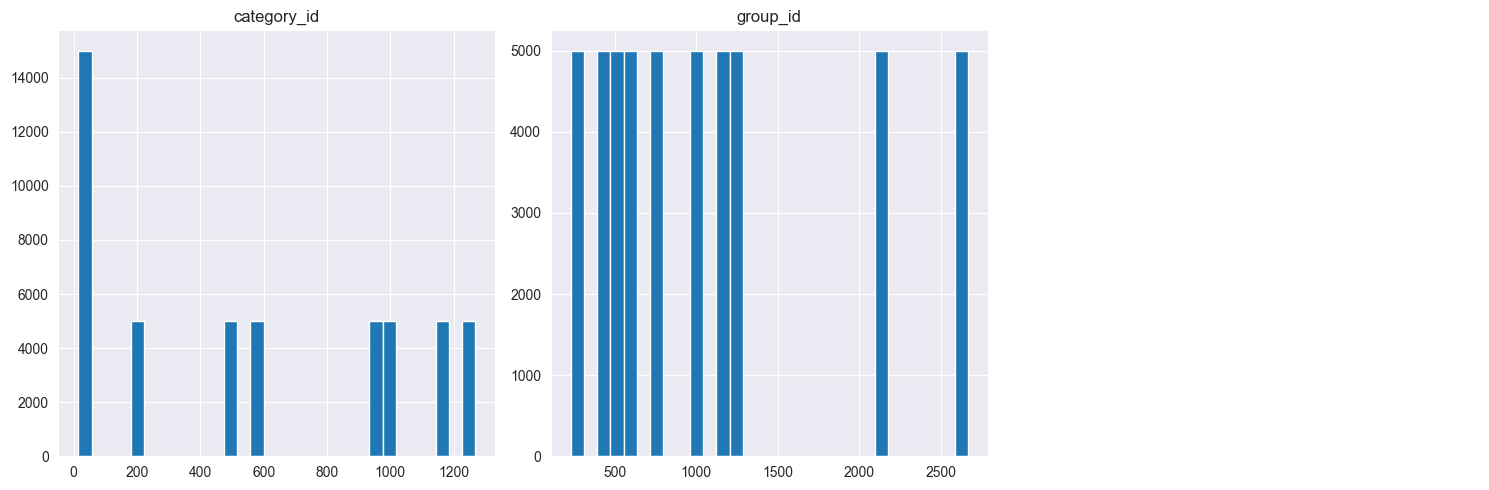

In [37]:
def hist_plot(ax, series, col_name):
    ax.hist(series.dropna(), bins=30)

plot_utils.plot_figure(df, num_cols, hist_plot)

### Categorical Columns

In [38]:
df[cat_cols].nunique()

category_name       10
group_name          10
name             42765
dtype: int64

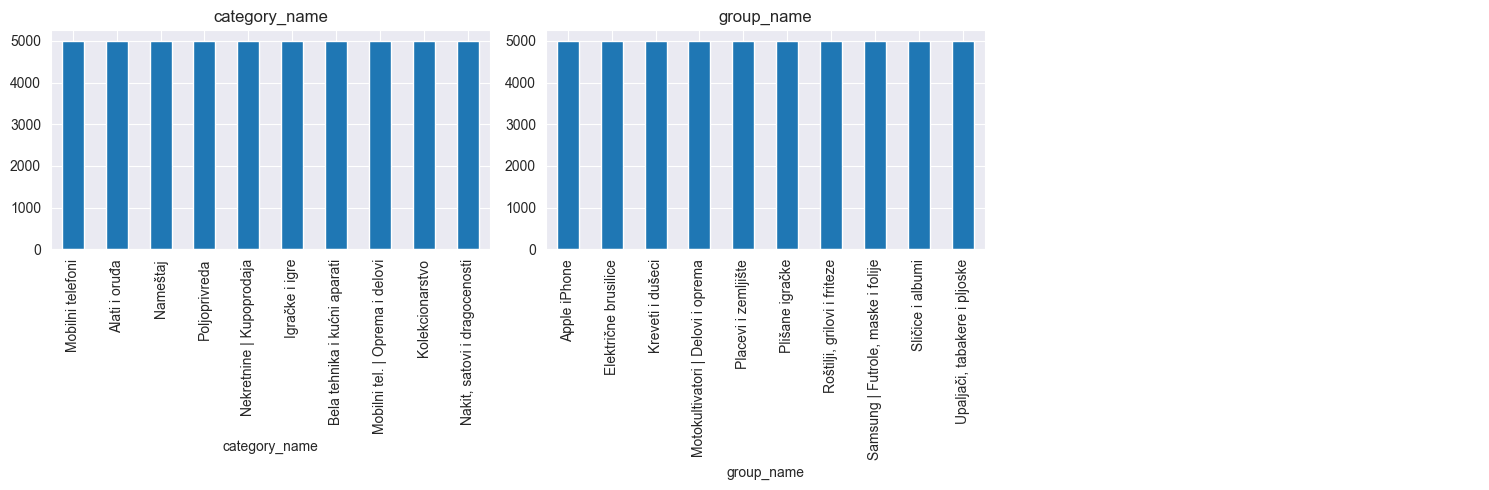

In [39]:
def bar_plot(ax, series, col_name):
    series.value_counts().plot(kind="bar", ax=ax)

plot_utils.plot_figure(df, [col for col in cat_cols if df[col].nunique() < 20], bar_plot)

## Bivariate Analysis

In [40]:
num_cols = df.select_dtypes(include=["number"]).columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns

cat_cols = [col for col in cat_cols if df[col].nunique() < 20]

### Numerical to Numerical

In [47]:
df[num_cols].corr()

,category_id,group_id
category_id,1.000000,0.002361
group_id,0.002361,1.000000


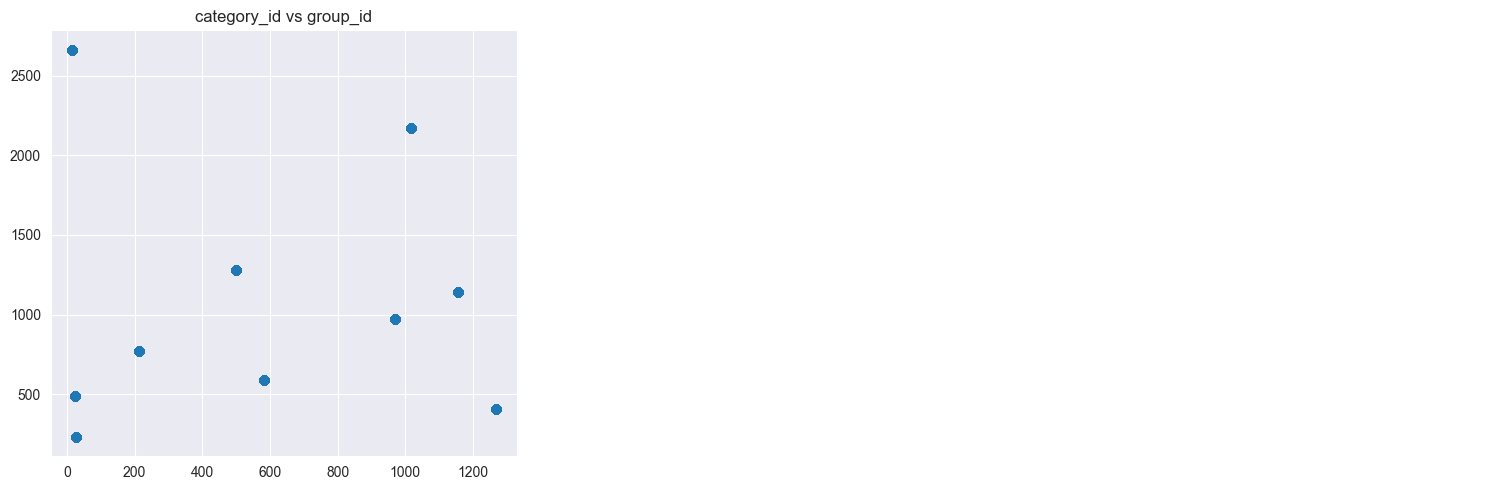

In [53]:
pairs = list(combinations(num_cols, 2))

def fn_scatter(ax, x, y, xname, yname):
    ax.scatter(x, y, alpha=0.4)

plot_utils.plot_figure_pairs(df, pairs, fn_scatter)

### Categorical to Numerical

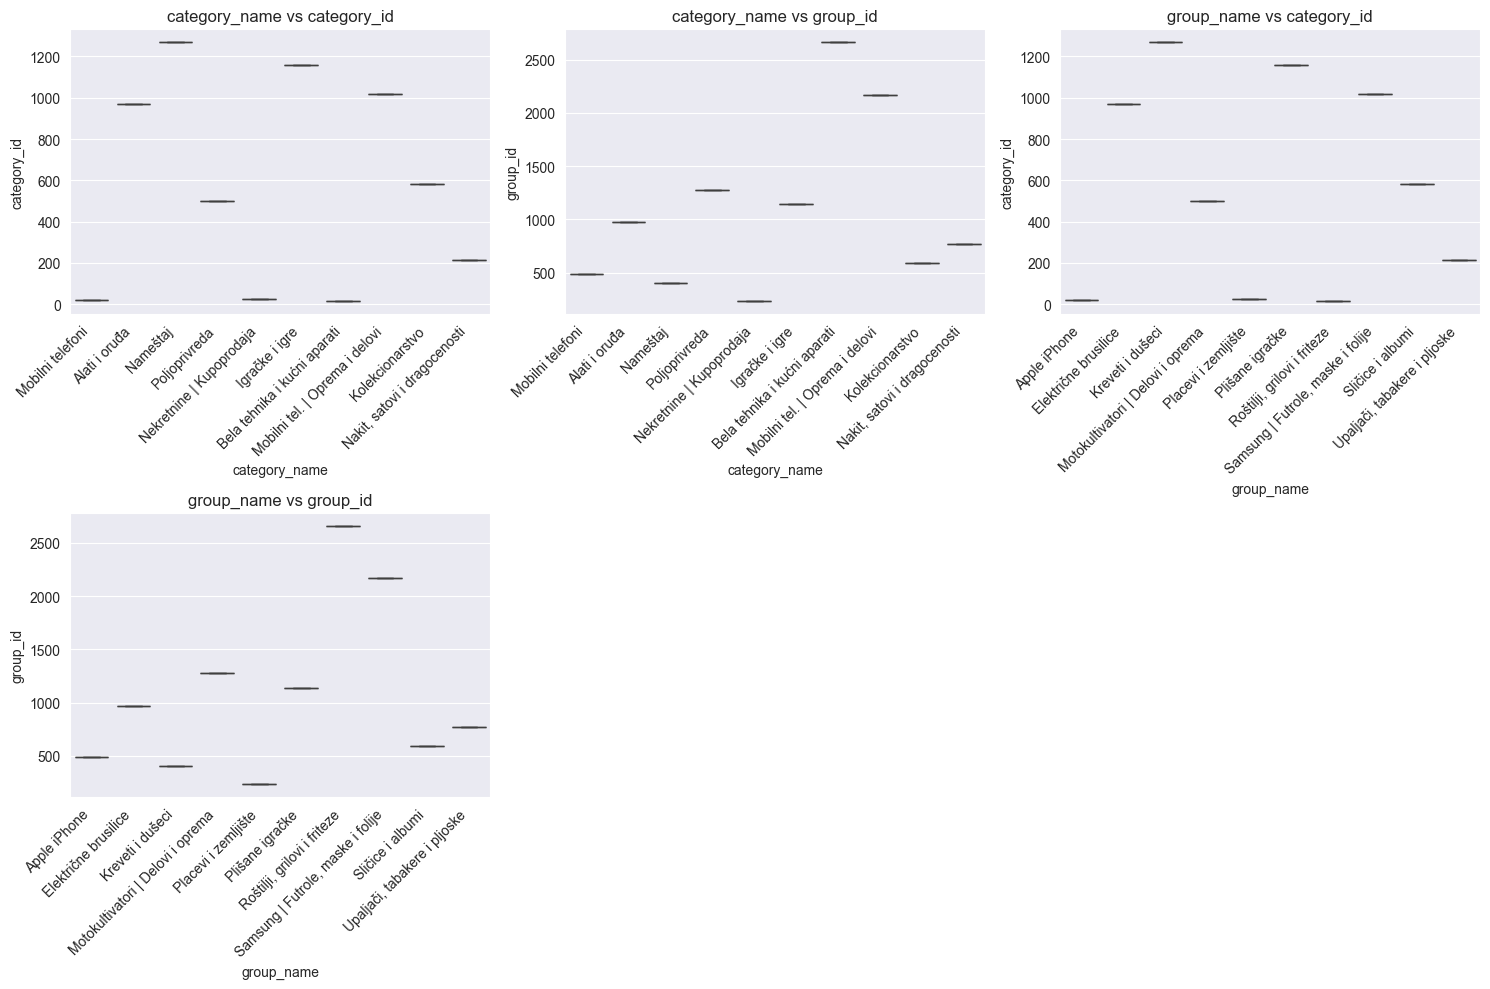

In [54]:
pairs = [(c, n) for c in cat_cols for n in num_cols]

def fn_box(ax, cat, num, cname, nname):
    sns.boxplot(x=cat, y=num, ax=ax)

    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')

plot_utils.plot_figure_pairs(df, pairs, fn_box)

### Categorical to Categorical

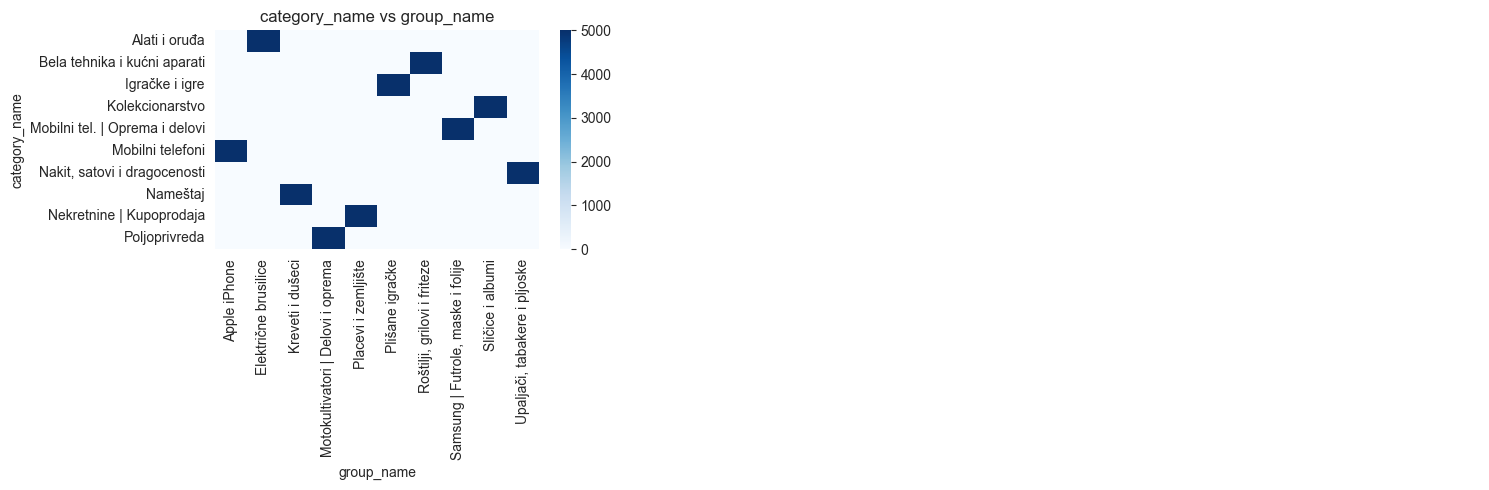

In [55]:
pairs = list(combinations(cat_cols, 2))

def fn_crosstab(ax, s1, s2, c1, c2):
    ct = pd.crosstab(s1, s2)
    sns.heatmap(ct, ax=ax, cmap="Blues")

plot_utils.plot_figure_pairs(df, pairs, fn_crosstab)

## Summary

### 1. Dataset Overview

- Rows: 50000
- Columns: 5
- Target variable: group_name
- Problem type: classification

### Observations:
- There are no missing values in dataset
- Duplicate values are trivial - advertisement names may be repeated, but they may not be identical rows
- Data types are consistent with expectations (numerical features are numeric, categorical features are strings)
- Numerical features are ids directly related to their respective categorical features, so they are not useful for modeling
- category_name is categorical feature that is directly related to target variable with coefficient 1, so it is not useful for modeling
- Only useful feature for modeling is advertisement name (name) and it is categorical feature with cardinality 42765

